In [3]:
import os
import json
from datasets import Dataset, DatasetDict

def load_tqa_dataset(data_dir):
    # Initialize empty lists to store data
    train_data = []
    val_data = []
    test_data = []

    # Define file paths
    train_file = os.path.join(data_dir,'train', 'tqa_v1_train.json')
    val_file = os.path.join(data_dir,'val', 'tqa_v1_val.json')
    test_file = os.path.join(data_dir,'test', 'tqa_v2_test.json')

    # Helper function to load JSON data
    def load_json(file_path):
        with open(file_path, 'r') as f:
            return json.load(f)

    # Load the data
    train_lessons = load_json(train_file)
    val_lessons = load_json(val_file)
    test_lessons = load_json(test_file)

    # Function to process lessons and questions
    def process_lessons(lessons):
        data = []
        for lesson in lessons:
            for question_type in ['nonDiagramQuestions', 'diagramQuestions']:
                if question_type in lesson['questions']:
                    for question_id, question in lesson['questions'][question_type].items():
                        data.append({
                            'lessonName': lesson['lessonName'],
                            'questionType': question_type,
                            'questionID': question_id,
                            'questionText': question['beingAsked']['processedText'],
                            'answerChoices': [choice['processedText'] for choice in question['answerChoices'].values()],
                            'correctAnswer': question['correctAnswer']['processedText'],
                            'imagePath': question.get('imagePath', None),
                            'imageName': question.get('imageName', None)
                        })
        return data

    # Process each split
    train_data = process_lessons(train_lessons)
    val_data = process_lessons(val_lessons)
    test_data = process_lessons(test_lessons)

    # Convert to Hugging Face datasets
    train_dataset = Dataset.from_dict({key: [d[key] for d in train_data] for key in train_data[0]})
    val_dataset = Dataset.from_dict({key: [d[key] for d in val_data] for key in val_data[0]})
    test_dataset = Dataset.from_dict({key: [d[key] for d in test_data] for key in test_data[0]})

    # Create a DatasetDict
    dataset_dict = DatasetDict({
        'train': train_dataset,
        'val': val_dataset,
        'test': test_dataset
    })

    return dataset_dict


In [6]:
# Example usage
# data_dir = './datasets/aokvqa/'  # Adjust this path to your data directory
data_dir = '../datasets_/tqa_train_val_test/'  # Adjust this path to your data directory
tqa_dataset = load_tqa_dataset(data_dir)

# Display dataset structure
print(tqa_dataset)

DatasetDict({
    train: Dataset({
        features: ['lessonName', 'questionType', 'questionID', 'questionText', 'answerChoices', 'correctAnswer', 'imagePath', 'imageName'],
        num_rows: 15154
    })
    val: Dataset({
        features: ['lessonName', 'questionType', 'questionID', 'questionText', 'answerChoices', 'correctAnswer', 'imagePath', 'imageName'],
        num_rows: 5309
    })
    test: Dataset({
        features: ['lessonName', 'questionType', 'questionID', 'questionText', 'answerChoices', 'correctAnswer', 'imagePath', 'imageName'],
        num_rows: 5797
    })
})


In [7]:
tqa_dataset['train']

Dataset({
    features: ['lessonName', 'questionType', 'questionID', 'questionText', 'answerChoices', 'correctAnswer', 'imagePath', 'imageName'],
    num_rows: 15154
})

Lesson: flatworms and roundworms
Question Type: diagramQuestions
Question: What does the circulatory system surround in this earthworm?
Answer Choices:
  a. Longitudinal muscle
  b. Circular muscle
  c. Crop
  d. Epidermis
Correct Answer: c
Associated Image:


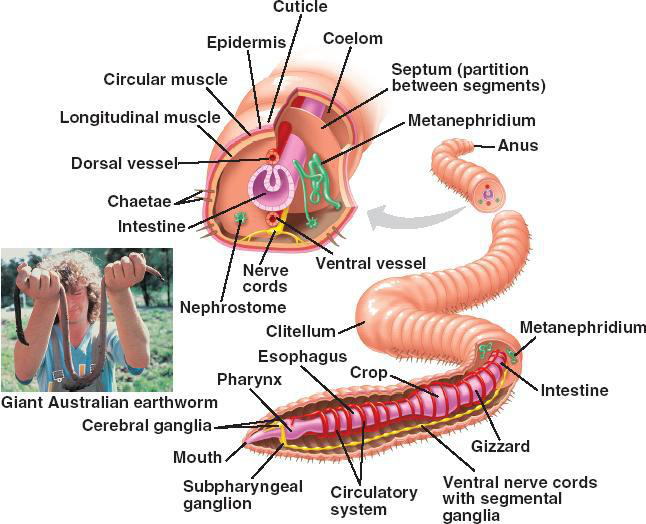


--------------------------------------------------------------------------------

Lesson: the microscope
Question Type: diagramQuestions
Question: Where is the head located?
Answer Choices:
  a. C
  b. H
  c. P
  d. V
Correct Answer: a
Associated Image:


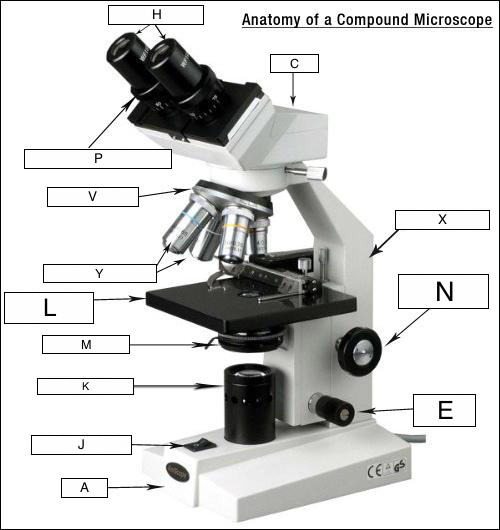


--------------------------------------------------------------------------------

Lesson: male reproductive system
Question Type: diagramQuestions
Question: What connects the testis to the ampulla?
Answer Choices:
  a. Seminal vesicle
  b. Vas deferens
  c. Ureter
  d. Urethra
Correct Answer: b
Associated Image:


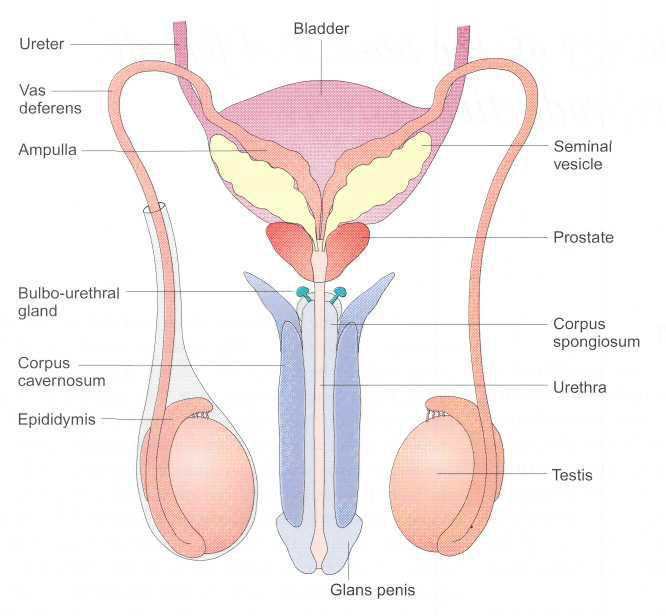


--------------------------------------------------------------------------------

Lesson: natural gas power
Question Type: nonDiagramQuestions
Question: natural gas is mostly composed of hydrocarbon ____________.
Answer Choices:
  a. propane
  b. methane
  c. butane
  d. benzene
Correct Answer: b

--------------------------------------------------------------------------------

Lesson: the muscular system
Question Type: diagramQuestions
Question: Which label shows the Myelin sheath?
Answer Choices:
  a. A
  b. R
  c. Y
  d. X
Correct Answer: b
Associated Image:


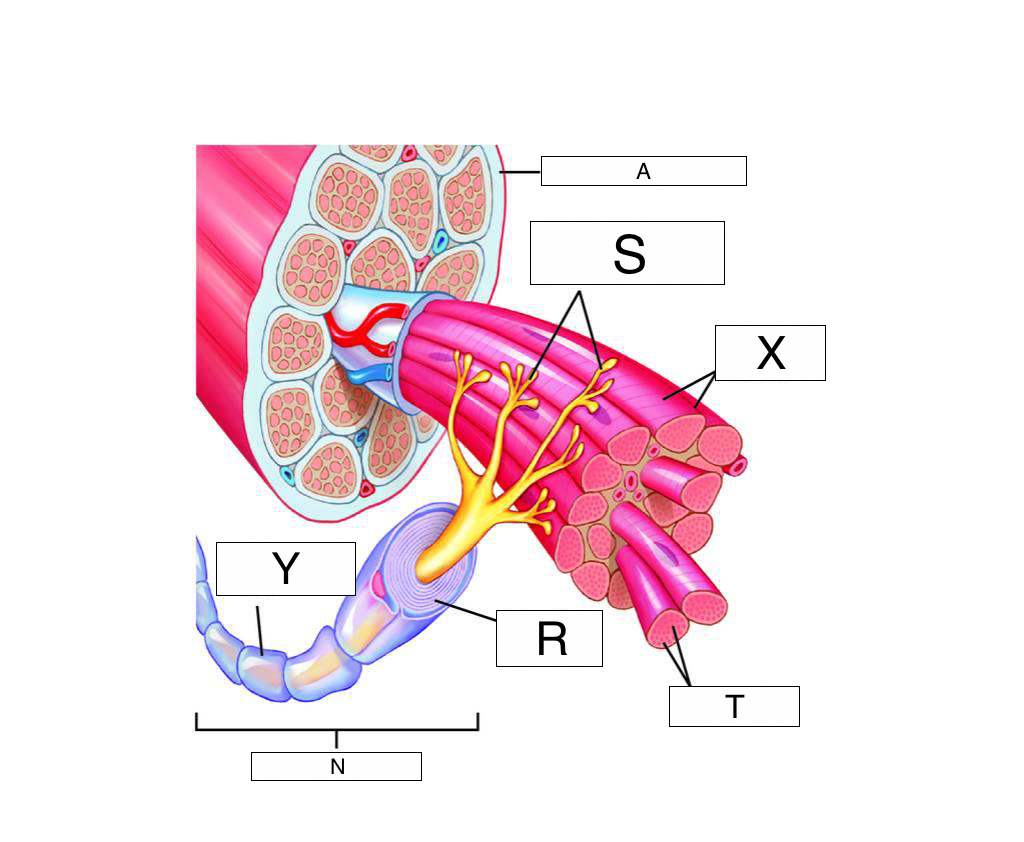


--------------------------------------------------------------------------------



In [9]:
import random
from IPython.display import Image, display


split = 'train'
num_samples = 5
split_dataset = tqa_dataset[split]
    
# Get random indices
random_indices = random.sample(range(split_dataset.num_rows), num_samples)
data_dir = '../datasets_/tqa_train_val_test/' 
for idx in random_indices:
    sample = split_dataset[idx]
    
    print(f"Lesson: {sample['lessonName']}")
    print(f"Question Type: {sample['questionType']}")
    print(f"Question: {sample['questionText']}")
    print("Answer Choices:")
    for i, choice in enumerate(sample['answerChoices']):
        print(f"  {chr(97 + i)}. {choice}")
    print(f"Correct Answer: {sample['correctAnswer']}")
    
    if sample['imagePath']:
        print("Associated Image:")
        path = os.path.join(data_dir, split, sample['imagePath'])
        display(Image(filename= path))
    
    print("\n" + "-"*80 + "\n")